# Glance fashion retrieval demo

Natural-language search over a fashion image collection, plus **live ingest** of a
brand-new image. All the logic lives in the `fashion_retrieval` package; this
notebook is just the demo driver.

**MAKE SURE, that the dataset is downloaded and unziped in data/ for the pipeline to work**

**How a query flows (all online, no VLM):**

1. **SigLIP** encodes the query once into a shared text/image latent space.
2. **Late fusion** over two FAISS indexes `text.faiss` (SigLIP text over the
   Qwen3-VL caption) and `image.faiss` (SigLIP image vectors):
   `score = a·text_sim + (1-a)·image_sim`.
3. **Rerank** adds an attribute-overlap boost (colors / garments / style / setting).

Offline, each image was captioned by **Qwen3-VL-2B** into structured attributes and
embedded by the **SigLIP image tower**, see `vlm.ipynb`.




In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "Notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from fashion_retrieval.retriever.retrieve import FusionRetriever

retriever = FusionRetriever() # loads text.faiss + image.faiss + records + SigLIP
print(f"ready — {len(retriever.records)} images indexed")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ready — 460 images indexed


## A pretty results grid

Renders hits as inline thumbnails with the fused score and its text/image split.

In [2]:
# --- display helper: an HTML thumbnail grid (PIL only, no matplotlib) ---
import base64, io, html
from PIL import Image
from IPython.display import HTML, display


def _thumb_uri(path, size=(200, 260)):
    try:
        im = Image.open(path).convert("RGB")
    except Exception:
        return None
    im.thumbnail(size)
    buf = io.BytesIO()
    im.save(buf, format="JPEG", quality=85)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()


def show_hits(query, hits, alpha=None):
    a = "" if alpha is None else f"  ·  a={alpha}"
    cards = []
    for rank, h in enumerate(hits, 1):
        uri = _thumb_uri(h["image_path"])
        img = (f'<img src="{uri}" style="width:100%;border-radius:8px 8px 0 0;'
               f'display:block;object-fit:cover;height:210px">'
               if uri else '<div style="height:210px;background:#eee"></div>')
        matched = ", ".join(h["matched"][:6]) or "—"
        cap = html.escape((h["caption"] or "")[:110])
        cards.append(f"""
        <div style="width:200px;border:1px solid #e5e5e5;border-radius:10px;
                    overflow:hidden;font-family:system-ui,sans-serif;background:#fff">
          {img}
          <div style="padding:8px 10px">
            <div style="font-weight:600;font-size:13px">#{rank} · score {h['score']:.3f}</div>
            <div style="font-size:11px;color:#666;margin:2px 0 6px">
              text {h['text_sim']:.2f} · img {h['image_sim']:.2f}</div>
            <div style="font-size:11px;color:#333;line-height:1.35">{cap}</div>
            <div style="font-size:10px;color:#0a7;margin-top:6px">✓ {html.escape(matched)}</div>
          </div>
        </div>""")
    header = (f'<div style="font-family:system-ui;font-size:15px;margin:6px 0 10px">'
              f' <b>{html.escape(query)}</b>{a}</div>')
    display(HTML(header + '<div style="display:flex;flex-wrap:wrap;gap:12px">'
                 + "".join(cards) + "</div>"))


def demo(query, k=5, a=None):
    hits = retriever.search(query, k=k, a=a)
    show_hits(query, hits, alpha=a)
    return hits


## Demo queries

Edit any of these - they're plain natural language.


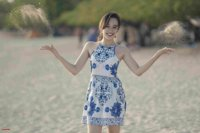
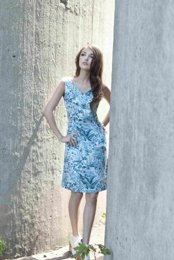
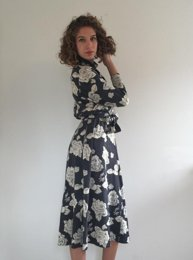
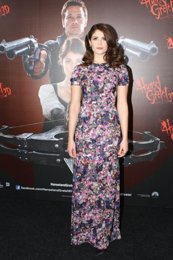
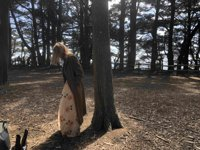

[{'id': 'image_00204',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_00204.jpg',
  'caption': 'A person wearing white blue floral embroidered halter dress, throwing, beach casual style, in beach.',
  'attributes': {'top': '',
   'bottom': '',
   'dress': 'white blue floral embroidered halter dress',
   'outerwear': '',
   'shoes': '',
   'accessories': '',
   'action': 'throwing',
   'style': 'beach casual',
   'environment': 'beach'},
  'score': 0.4635,
  'fused': 0.4035,
  'text_sim': 0.6929,
  'image_sim': 0.1141,
  'matched': ['dress', 'floral']},
 {'id': 'image_00401',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_00401.jpg',
  'caption': 'A person wearing light blue floral fitted dress, white block heels, posing, elegant casual style, in urban alley.',
  'attributes': {'top': '',
   'bottom': '',
   'dress': 'light blue floral fitted dress',
   'outerwear': '',
   'shoes': 'white block heels',
   'accessories': '

In [4]:
demo("woman in a floral summer dress outdoors", k=5)



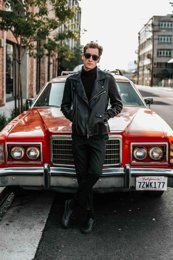
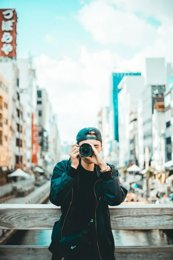
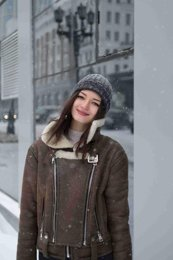
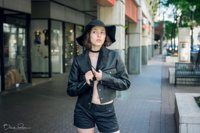
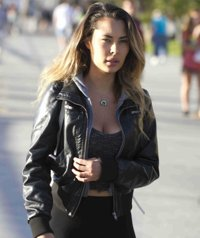

[{'id': 'image_00372',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_00372.jpg',
  'caption': 'A person wearing black turtleneck, black pants, black biker jacket, black boots, with black glasses, posing, streetwear style, in city street.',
  'attributes': {'top': 'black turtleneck',
   'bottom': 'black pants',
   'dress': '',
   'outerwear': 'black biker jacket',
   'shoes': 'black boots',
   'accessories': 'black glasses',
   'action': 'posing',
   'style': 'streetwear',
   'environment': 'city street'},
  'score': 0.5197,
  'fused': 0.4072,
  'text_sim': 0.6671,
  'image_sim': 0.1473,
  'matched': ['city', 'jacket', 'street']},
 {'id': 'image_00174',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_00174.jpg',
  'caption': 'A person wearing black t-shirt, black pants, black fitted jacket, with black hat, gold watch, posing, casual streetwear style, in city street.',
  'attributes': {'top': 'black t-shirt',
   'bottom': 

In [18]:
demo("person in a leather jacket on a city street", k=5)


## The fusion knob: caption vs. image

Same query, three settings of `a`. `a=1` scores only the Qwen3-VL caption text,
`a=0` scores only the raw SigLIP image embedding, `a=0.5` blends them.



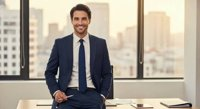
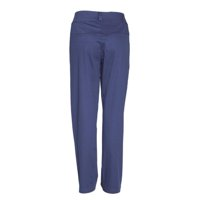
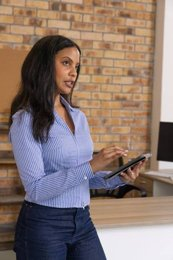
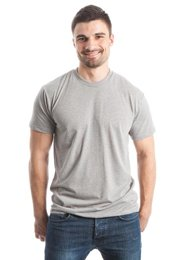


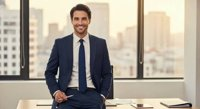
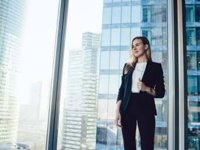
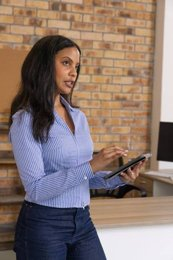
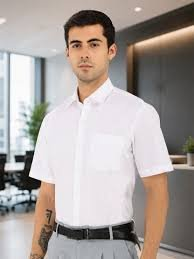


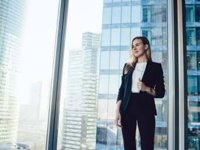
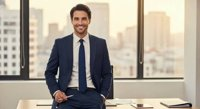
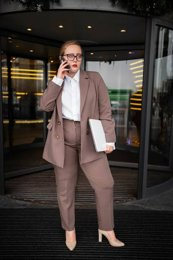
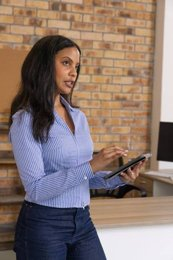

In [21]:
q = "Professional business attire inside a modern office."
for a in (1.0, 0.5, 0.0):
    demo(q, k=4, a=a)


---
# Upload a new image (live ingest)

Testing Zero-Shot capabilities

Add an image the index has never seen. It gets **captioned by Qwen3-VL** and
**embedded by SigLIP**, written into the file DBs, and made searchable — the full
offline pipeline, on one image, live.

**Run the picker cell below.**
- If `ipywidgets` is installed you'll get a file-upload button.
- Otherwise, set `UPLOAD_PATH` to any image on disk (or drop files into
  `data/incoming/` and leave it as `None`).


In [7]:
# --- pick an image to ingest ---
from fashion_retrieval.configs.config import CONFIG

INCOMING = CONFIG.incoming_dir
INCOMING.mkdir(parents=True, exist_ok=True)

# Fallback: point this at any image file, or leave None to use data/incoming/
UPLOAD_PATH = None

_uploaded = []  # filled by the widget, if available
try:
    import ipywidgets as widgets
    from IPython.display import display

    _uploader = widgets.FileUpload(accept="image/*", multiple=True,
                                   description="Upload image(s)")

    def _on_upload(change):
        _uploaded.clear()
        for name, meta in _uploader.value.items() if isinstance(_uploader.value, dict) \
                else ((f["name"], f) for f in _uploader.value):
            dst = INCOMING / name
            dst.write_bytes(meta["content"])
            _uploaded.append(str(dst))
        print(f"saved {len(_uploaded)} file(s) to {INCOMING}/")

    _uploader.observe(_on_upload, names="value")
    display(_uploader)
    print("↑ click to upload, then run the ingest cell")
except ImportError:
    print("ipywidgets not installed — set UPLOAD_PATH to an image, "
          f"or drop files into {INCOMING}/ and run the ingest cell")


FileUpload(value=(), accept='image/*', description='Upload image(s)', multiple=True)

↑ click to upload, then run the ingest cell


model.safetensors:   0%|          | 0.00/2.41G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/home/jitdarkfighter/Projects/Glance/.venv/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



=== image_01000  <-  /home/jitdarkfighter/Projects/Glance/data/sampled_images/image_01000.jpg ===
{
  "top": "helmet",
  "top_color": "white",
  "top_features": [],
  "bottom": "body armor",
  "bottom_color": "black",
  "bottom_features": [],
  "dress": null,
  "dress_color": null,
  "dress_features": [],
  "outerwear": "body armor",
  "outerwear_color": "black",
  "outerwear_features": [],
  "shoes": "combat boots",
  "shoes_color": "black",
  "accessories": [
    {
      "item": "helmet",
      "color": "white"
    }
  ],
  "action": "sitting",
  "style": "dark fantasy",
  "environment": "ancient hall"
}



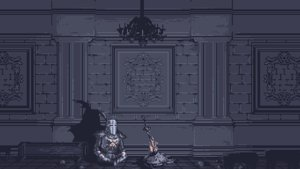

In [9]:
# Ingest cell 
import shutil
from fashion_retrieval.indexer.ingest import Ingestor

# reuse the retriever's SigLIP so we don't load it twice; only Qwen3-VL loads fresh here
ingestor = Ingestor(encoder=retriever.encoder)

# resolve the source list: widget uploads > UPLOAD_PATH > anything already in incoming/
sources = list(_uploaded)
if not sources and UPLOAD_PATH:
    dst = INCOMING / Path(UPLOAD_PATH).name
    if Path(UPLOAD_PATH).resolve() != dst.resolve():
        shutil.copy(UPLOAD_PATH, dst)
    sources = [str(dst)]

if sources:
    ingested = [ingestor.ingest_image(s) for s in sources]      # explicit picks
else:
    ingested = ingestor.ingest_folder(str(INCOMING))            # or drain incoming/

if not ingested:
    print("nothing to ingest - upload a file, set UPLOAD_PATH, or fill data/incoming/")

import json
for stem, path, meta in ingested:
    print(f"\n=== {stem}  <-  {path} ===")
    print(json.dumps(meta, indent=2)[:800])
    display(HTML(f'<img src="{_thumb_uri(path, (300, 380))}" '
                 f'style="border-radius:8px;max-height:320px">'))


## Rebuild the index and find the new image

Ingest wrote the per-image JSON + `.npy` immediately; now rebuild the two FAISS
indexes (cheap — it reuses the stored vectors) and reload the retriever. Then we
build a query straight from the new image's own attributes so it should surface.


In [ ]:
from fashion_retrieval.indexer.index import build_indexes
from fashion_retrieval.indexer.attributes import attrs_to_text

build_indexes()                                   # text.faiss + image.faiss + records.jsonl
retriever = FusionRetriever(encoder=retriever.encoder)   # reload with the new rows
print(f"reindexed — {len(retriever.records)} images now searchable")


[1/2] Text index: embedding 461 captions with google/siglip2-base-patch16-224 ...
[2/2] Image index: stacking 461 stored SigLIP vectors ...
Done. text=/home/jitdarkfighter/Projects/Glance/data/index/text.faiss  image=/home/jitdarkfighter/Projects/Glance/data/index/image.faiss  records=/home/jitdarkfighter/Projects/Glance/data/index/records.jsonl
reindexed — 461 images now searchable


# Now you can try to retrieve your image :)


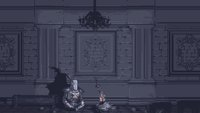
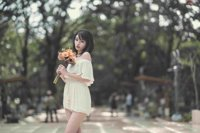
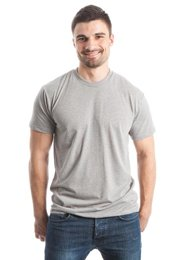
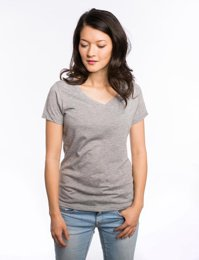
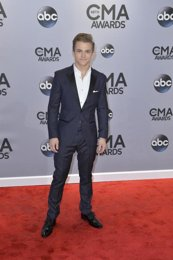

[{'id': 'image_01000',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_01000.jpg',
  'caption': 'A person wearing white helmet, black body armor, black body armor, black combat boots, with white helmet, sitting, dark fantasy style, in ancient hall.',
  'attributes': {'top': 'white helmet',
   'bottom': 'black body armor',
   'dress': '',
   'outerwear': 'black body armor',
   'shoes': 'black combat boots',
   'accessories': 'white helmet',
   'action': 'sitting',
   'style': 'dark fantasy',
   'environment': 'ancient hall'},
  'score': 0.3893,
  'fused': 0.3393,
  'text_sim': 0.5711,
  'image_sim': 0.1075,
  'matched': ['armor']},
 {'id': 'image_00394',
  'image_path': '/home/jitdarkfighter/Projects/Glance/data/sampled_images/image_00394.jpg',
  'caption': 'A person wearing cream off-shoulder top, cream shorts, posing, casual style, in park.',
  'attributes': {'top': 'cream off-shoulder top',
   'bottom': 'cream shorts',
   'dress': '',
   'outerwear': '

In [15]:
demo("A knight in shining armor", k=5)


# Evaluation Queries


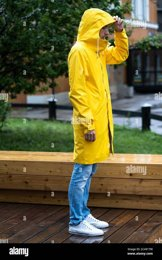
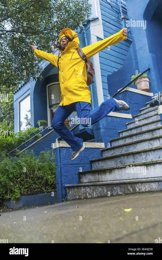
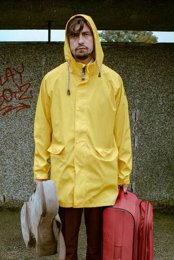
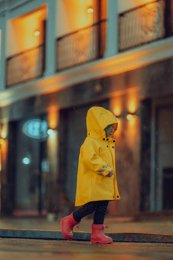
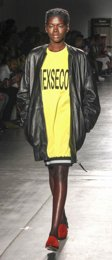


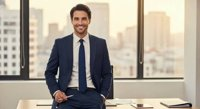
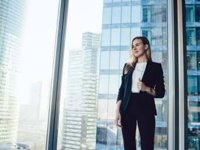
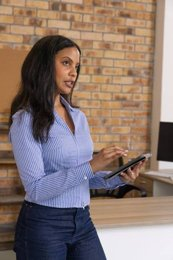
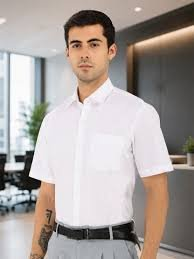
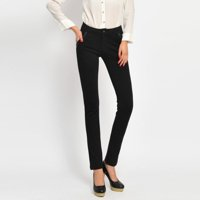


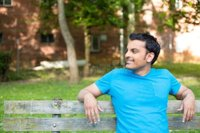
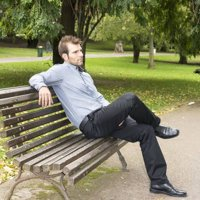
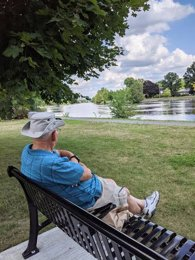
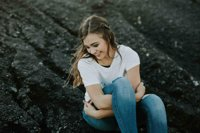
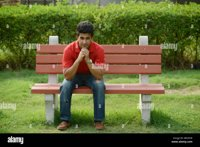


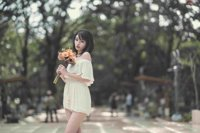
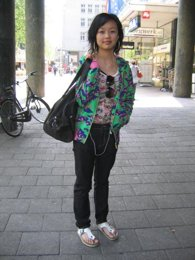
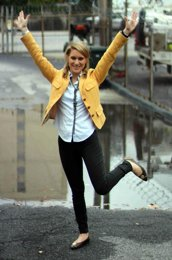
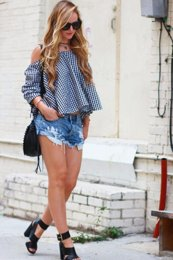
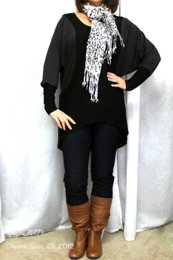


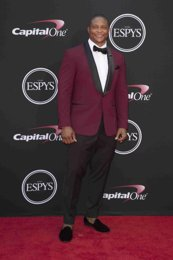
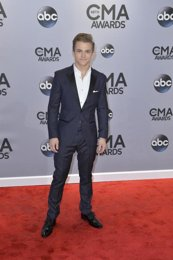
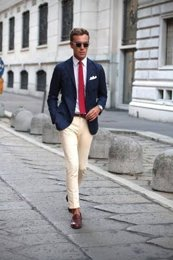
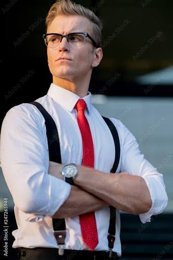
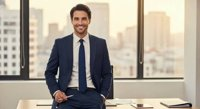

'Reason for bad red-tie retrieval: I noticed that the model does not annotate ties. Purposefuly left it that way to show the use \nof the text+image fusion. Without this, no red-tie image would have been retrieved. Atleast now its ranked 2nd and 3rd in the top-5 results'

In [25]:
demo("A person in a bright yellow raincoat.", k=5)
demo("Professional business attire inside a modern office.", k=5)
demo("Someone wearing a blue shirt sitting on a park bench.", k=5)
demo("Casual weekend outfit for a city walk.", k=5)
demo("A red tie and a white shirt in a formal setting.", k=5) 

"""Reason for bad red-tie retrieval: I noticed that the model does not annotate ties. Purposefuly left it that way to show the use 
of the text+image fusion. Without this, no red-tie image would have been retrieved. Atleast now its ranked 2nd and 3rd in the top-5 results"""